# Hungarian Dataset Simulation and Optimization

In [1]:
from utils import data_path, tech_colors, cost_params, week_numbers, seasons
from utils import change_costs
from visualizations import plot_generator_t, plot_generator_t_plotly

import numpy as np
import pandas as pd

import pypsa

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Create analyzed dates
- **week 15**: April 8 - April 14
- **week 28**: July 08 - July 14
- **week 40**: September 30 - October 06
- **week 49**: December 02 - December 08

In [2]:
dates = []
start_date = pd.to_datetime('2000-01-01') # dummy start date
for week in week_numbers.values():
    s = start_date + pd.Timedelta(weeks=week-1)
    e = s + pd.Timedelta(days=6, hours=23)
    dates.append(pd.date_range(start=s ,end=e, freq='h').to_list())

# Import Data

In [3]:
potentials_generator = pd.read_excel(data_path, sheet_name='potentials_generator', index_col=0, na_values='None')
potentials_storage = pd.read_excel(data_path, sheet_name='potentials_storage', index_col=0, na_values='None')
costs_generator = pd.read_excel(data_path, sheet_name='costs_generator', index_col=0, na_values='None').to_dict()
costs_storage = pd.read_excel(data_path, sheet_name='costs_storage', index_col=0, na_values='None').to_dict()
profile_wind = pd.read_excel(data_path, sheet_name='profile_wind', names=list(week_numbers.keys()), header=None, index_col=0)
profile_PV = pd.read_excel(data_path, sheet_name='profile_PV', names=list(week_numbers.keys()), header=None, index_col=0)
demand = pd.read_excel(data_path, sheet_name='demand').values.ravel()

#### Changing cost paramteres to time dependent cost
- In the future it may be replaced with stock market data.

In [4]:
#change_costs(costs_generator, ['Nuclear', 'Solar'], ['operation'], 
#             function=np.random.uniform, low=0.95, high=1.05, size=demand.shape)

# PyPSA - Network & Optimizations

- [Generator parameters](https://docs.pypsa.org/latest/api/components/types/generators/#pypsa.components.Generators.add) 
- [Storage Unit paramaters](https://docs.pypsa.org/latest/api/components/types/storage-units/#pypsa.components.StorageUnits.add)
    <!--     - `p_nom` / `p_nom_extendable`: nominális teljesítmény (korlátoztható/bővíthető)
    - `p_nom_min` / `p_nom_max` / `p_nom_set`
    - `p_min_pu` / `p_max_pu`: min input / max output for each snapshot
    --->




- [HiGHS](https://en.wikipedia.org/wiki/HiGHS_optimization_solver)

In [5]:
# Building the network
network = pypsa.Network(name='Network')

# Time stamps
snapshots = np.array([item for sublist in dates for item in sublist])
network.set_snapshots(list(snapshots))

# Base electrical network
network.add(class_name="Bus", 
            name="country_0",
            carrier='AC'
           )

# Set a carrier for the network
network.add(class_name='Carrier',
            name='AC'
           )

# Add demand to the network
network.add(class_name="Load", 
            name="Residential demand",  
            bus="country_0", 
            p_set=demand
           )   

# Save cost parameters to the network
network.meta['costs_generator']=costs_generator
network.meta['costs_storage']=costs_storage

# Add generators to the network
for technology in potentials_generator.keys(): 
    p_max_pu=1
    p_min_pu=0
    committable=False

    # getting profiles 
    if technology in ['Solar']:
        p_max_pu=np.repeat(profile_PV.values, 7, axis=1).flatten('F') # column-major order
    elif technology in ['Wind Onshore']:
        p_max_pu=np.repeat(profile_wind.values, 7, axis=1).flatten('F')
    elif technology in ['Nuclear']:
        p_min_pu=0.8
        #committable=True
    
    # adding generators
    network.add(class_name="Generator", 
                name=str(technology),
                #nicename=str(technology),
                bus="country_0",
                
                #p_nom=potentials_generator.loc['p_nom'][str(technology)],
                p_nom_extendable=True, # optimisable generator capacity
                p_nom_max=potentials_generator.loc['p_nom_max'][str(technology)], # maximum limit
                p_nom_min=potentials_generator.loc['p_nom_min'][str(technology)], # minimum limit
                capital_cost=costs_generator[str(technology)]['capital'], # generator installation cost
                marginal_cost=sum([costs_generator[str(technology)][key] for key in cost_params[1:]]), # operating cost
                p_max_pu=p_max_pu, # maximum power per-unit // production profiles
                p_min_pu=p_min_pu,
                ramp_limit_up=potentials_generator.loc['ramp_up'][str(technology)],   # maximum increase per hour
                ramp_limit_down=potentials_generator.loc['ramp_down'][str(technology)], # maximum decrease per hour

                #committable=committable,
                #ramp_limit_start_up=0.75,
                #ramp_limit_shut_down=0.75
            )
   
# Storage units creation
for technology in potentials_storage.keys():
    network.add(class_name="StorageUnit", 
                name=str(technology),
                bus="country_0",
                
                p_nom_extendable=True, # optimisable storage capacity
                p_nom_max=potentials_storage.loc['p_nom_max'][str(technology)], # maximum limit
                capital_cost=costs_storage[str(technology)]['capital'], # installation cost
                marginal_cost=sum([costs_storage[str(technology)][key] for key in cost_params[1:]]), # operating cost
            )
    
# Optimization
network.sanitize()
network.optimize(solver_name='highs', 
                 #linearized_unit_commitment=True,
                 log_to_console=True,
                 solver_options={'presolve': 'on', 
                                 'threads': 'all',
                                 'time_limit': 3600,
                                 'solver': 'simplex', # simplex/ipm/pdlp
                                 'parallel': 'on',
                                 'run_crossover': 'off',
                                 }
                )

INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Assigned colors to 1 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - presolve: on
 - threads: all
 - time_limit: 3600
 - solver: simplex
 - parallel: on
 - run_crossover: off
 - log_to_console: True
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 90.98it/s]
INFO:linopy.io: Writing time: 0.87s


Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-yk1iybzd has 45028 rows; 12783 cols; 107862 nonzeros
Coefficient ranges:
  Matrix  [5e-05, 1e+00]
  Cost    [1e-01, 2e+04]
  Bound   [0e+00, 0e+00]
  RHS     [3e+01, 6e+03]
Presolving model
23334 rows, 8467 cols, 67257 nonzeros 0s
Dependent equations search running on 1343 equations with time limit of 36.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 36.00s)
23332 rows, 8465 cols, 67251 nonzeros 0s
Presolve reductions: rows 23332(-21696); columns 8465(-4318); nonzeros 67251(-40611) 
Solving the presolved LP
Using parallel dual simplex solver - PAMI with concurrency of 8
  Iteration        Objective     Infeasibilities num(sum)
          0    -8.3595614162e+06 Ph1: 2128(1.67052e+06); Du: 672(8359.56) 0.2s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 12783 primals, 45054 duals
Objective: 6.98e+07
Solver: highs
Runtime: 2.19s
MIP gap: inf
Dual bound: 0.00e+00
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Generator-p-ramp_limit_up, Generator-p-ramp_limit_down, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


      10584     6.9793700721e+07 Pr: 0(0); Du: 0(9.98135e-12) 2.1s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-yk1iybzd
Model status        : Optimal
Simplex   iterations: 10584
Objective value     :  6.9793700721e+07
P-D objective error :  4.3020844690e-14
HiGHS run time      :          2.19


('ok', 'optimal')

In [6]:
network.generators.p_nom_opt

name
Solar                     489.031208
Wind Offshore              -0.000000
Wind Onshore             2000.000000
Hydro Run-of-river         36.000000
Hydro Water Reservoir      28.000000
Geothermal                 -0.000000
Biomass                    -0.000000
Waste                     300.000000
Fossil Lignite            600.000000
Fossil Hard coal           -0.000000
Fossil Gas                478.662894
Nuclear                  2297.823472
Fusion                     -0.000000
Name: p_nom_opt, dtype: float64

In [7]:
network.storage_units.p_nom_opt

name
Pumped Storage Actual    156.111247
Storage Actual            -0.000000
Name: p_nom_opt, dtype: float64

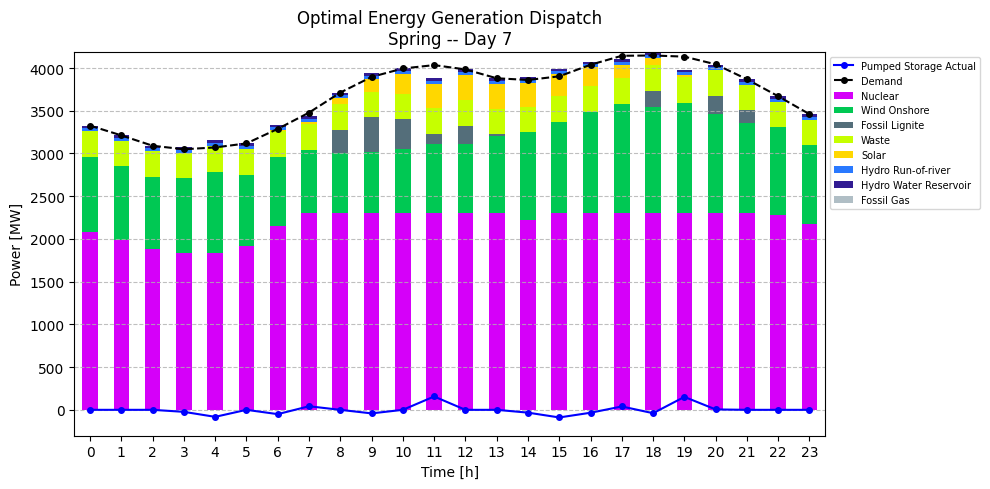

In [8]:
season, day = 'Spring', 7
plot_generator_t(network, dates, season=season, day=day, colors=tech_colors, demand=demand, 
                 savefig=f'figures/02_hungary/energy_dispatch_{season.lower()}_day{day}.pdf')

In [9]:
# create interactive plots for each season
for season in seasons.keys():
    plot_generator_t_plotly(network,  
                            dates,
                            season,
                            colors=tech_colors,
                            savefig=f'figures/02_hungary/energy_dispatch_{season.lower()}.html',
                            demand=demand
                            )